In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [14]:
DATA_ROOT = "/workspace/yb-soc-two-body-loss/data/fig4b"

In [15]:
def query_condition(name):
    return True

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

run_0_nh_13_5_09081715
run_1_nh_13_5_09081722
run_2_nh_13_5_09081728
run_3_nh_13_5_09081735
run_4_nh_13_5_09081742
run_5_nh_13_5_09081748
run_6_nh_13_5_09081755
run_7_nh_13_5_09081802
run_8_nh_13_5_09081809
run_9_nh_13_5_09081815
run_10_nh_13_5_09081823


In [16]:
DATA_SUBDIR_LIST = [
    "run_0_nh_13_5_09081715",
    "run_1_nh_13_5_09081722",
    "run_2_nh_13_5_09081728",
    "run_3_nh_13_5_09081735",
    "run_4_nh_13_5_09081742",
    "run_5_nh_13_5_09081748",
    "run_6_nh_13_5_09081755",
    "run_7_nh_13_5_09081802",
    "run_8_nh_13_5_09081809",
    "run_9_nh_13_5_09081815",
    "run_10_nh_13_5_09081823"
]
DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [ ]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

def load_nh_state_norm_square(data_dir):
    state_norm_sq = load_nparray(data_dir, "state_norm_square_nh.npy")
    return state_norm_sq

In [18]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

In [19]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [20]:
merged_params, merged = merge_params(params)
# print(merged)
# pointer = merged_params
# for key in merged[0].split('.'):
#     pointer = pointer[key]
# print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

{
    "k0": 0.5,
    "n_particles": 5,
    "m_Yb": 1.0,
    "pa": {
        "gamma": 0.38,
        "T2": 1.25
    },
    "simulation_settings": {
        "t0": 0,
        "t1": 2.0,
        "mode": "non-Hermitian",
        "n_savesteps": 51,
        "step_size": 0.354295837023915,
        "n_trajectories": 512,
        "batch_size": 64,
        "jumps_per_step": 4,
        "num_batches": 8,
        "total_n_steps": 200,
        "delta_t": 0.08857395925597875,
        "seed": 0
    },
    "L": 12.566370614359172,
    "n_momentum_points": 13,
    "hbar": 1.0
}


In [21]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

error: 0.0


In [22]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [23]:
exp_pol_data_path = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_4_b_upper.csv"
exp_loss_data_path = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_4_b_lower.csv"

In [ ]:
import pandas as pd
df_pol = pd.read_csv(exp_pol_data_path)
df_loss = pd.read_csv(exp_loss_data_path)
time_exp = np.array(df_pol["time"])[:11] * 1000 # s -> ms
pol_exp = np.array(df_pol["mean"])[:11]
pol_error_exp = np.array(df_pol["se"])[:11]

loss_exp = np.array(df_loss["mean"])[::2]
loss_error_exp = np.array(df_loss["se"])[::2]

In [48]:
# gather numerical data
ts_numerical = np.linspace(0.0, 0.4, 11)
ts_dense = np.linspace(0.0, 0.4, 201)
soc_data_dir = "/workspace/yb-soc-two-body-loss/data/soc_evolutions/13_5_09081644"
up_nums = load_nparray(soc_data_dir, "up_nums_momentum.npy")
down_nums = load_nparray(soc_data_dir, "down_nums_momentum.npy")

up = up_nums[:, 8]
down = down_nums[:, 8]
dense_pol = (up - down) / (up + down)

loss = np.zeros((11,))
loss_error = np.zeros((11,))
loss_nh = np.zeros((11,))
loss_error_nh = np.zeros((11,))

for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params = load_params(data_dir)
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    norm_sq_nh = load_nh_state_norm_square(data_dir)
    assert nums_up.shape == nums_down.shape
    n_traj = nums_up.shape[0]
    n_particles = params["n_particles"]
    nums_up /= n_particles
    nums_down /= n_particles
    
    total_up = np.sum(nums_up, axis=2)
    total_down = np.sum(nums_down, axis=2)
    
    remained = 1 - (total_up[:, -1] + total_down[:, -1])
    remained_nh = 1 - ((norm_sq_nh[:, -1] * 2 + (n_particles - 2)) / n_particles)
    
    loss[idx] = np.mean(remained)
    loss_error[idx] = np.std(remained)
    
    loss_nh[idx] = np.mean(remained_nh)
    loss_error_nh[idx] = np.std(remained_nh)

In [ ]:
def query_condition(name):
    return True

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

run_0_nh_13_5_09081715
run_1_nh_13_5_09081722
run_2_nh_13_5_09081728
run_3_nh_13_5_09081735
run_4_nh_13_5_09081742
run_5_nh_13_5_09081748
run_6_nh_13_5_09081755
run_7_nh_13_5_09081802
run_8_nh_13_5_09081809
run_9_nh_13_5_09081815
run_10_nh_13_5_09081823


In [34]:
from scipy.optimize import curve_fit

def decaying_sine(t, a, b, c, d, e):
    return a + b * np.exp(c * t) * np.cos(d * t + e)

initial_guess = [0, 1, -0.1, 2, 0]
popt, pcov = curve_fit(decaying_sine, time_exp[:11], pol_exp[:11], p0=initial_guess)

exp_pol_fit = decaying_sine(ts_dense, *popt)

In [30]:
dense_pol.shape

(201,)

In [38]:
pol_exp.shape

(21,)

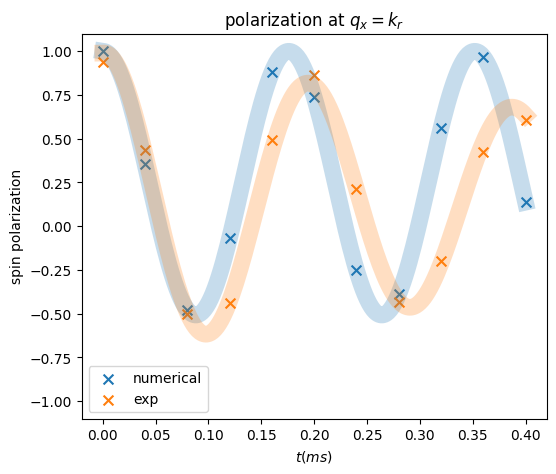

In [40]:
plt.figure(figsize=(6, 5))

plt.title("polarization at $q_x = k_r$")

plt.plot(ts_dense, dense_pol, linewidth=12, alpha=0.25, color='tab:blue')
plt.plot(ts_dense, exp_pol_fit, linewidth=12, alpha=0.25, color='tab:orange')

plt.scatter(ts_numerical, dense_pol[0::20], s=50, marker='x', color='tab:blue', label="numerical")
plt.scatter(ts_numerical, pol_exp[:11], s=50, marker='x', color='tab:orange', label="exp")

plt.ylabel("spin polarization")
plt.xlabel("$t (ms)$")
plt.ylim(-1.1, 1.1)

plt.legend()
plt.show()

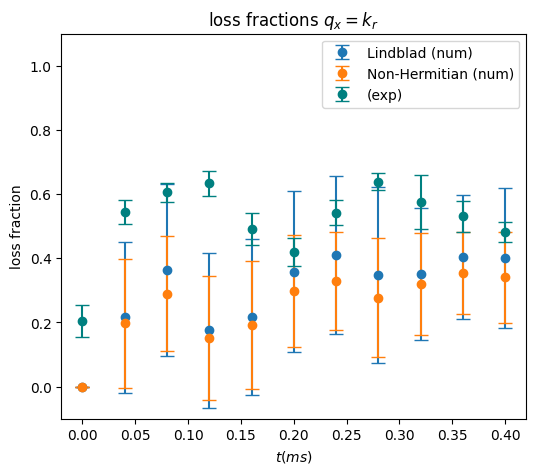

In [52]:
plt.figure(figsize=(6, 5))

plt.title("loss fractions $q_x = k_r$")

plt.errorbar(ts_numerical, loss, yerr=loss_error, fmt='o', capsize=5, color='tab:blue', label="Lindblad (num)")
plt.errorbar(ts_numerical, loss_nh, yerr=loss_error_nh, fmt='o', capsize=5, color='tab:orange', label="Non-Hermitian (num)")
plt.errorbar(ts_numerical, loss_exp[::2], yerr=loss_error_exp[::2], fmt='o', capsize=5, color='teal', label='(exp)')

plt.ylabel("loss fraction")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

In [ ]:
ts = ts_ref
ts_ms = ts_ref * t_r
print(f"{len(ts)=}")
print(ts_ms)

len(ts)=51
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.  ]


In [ ]:
n_particles = merged_params['n_particles']

In [ ]:
n_particles

[2, 3, 4, 5, 6]

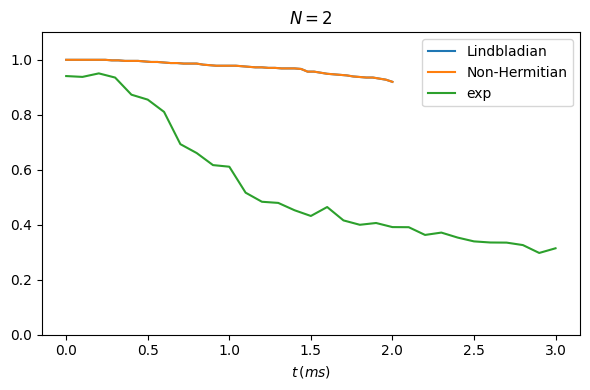

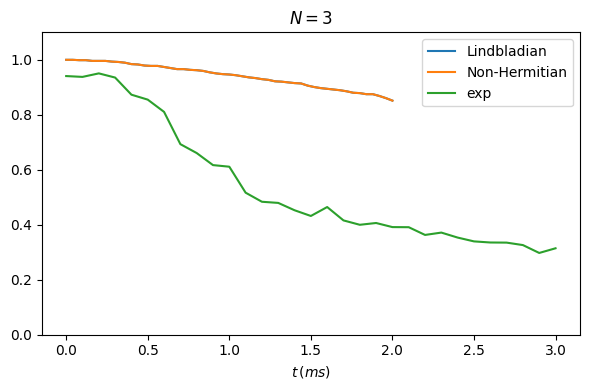

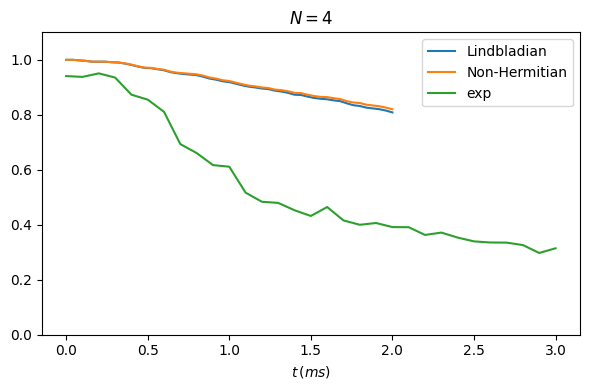

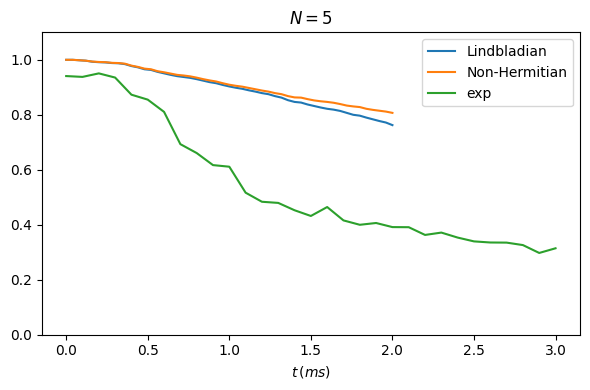

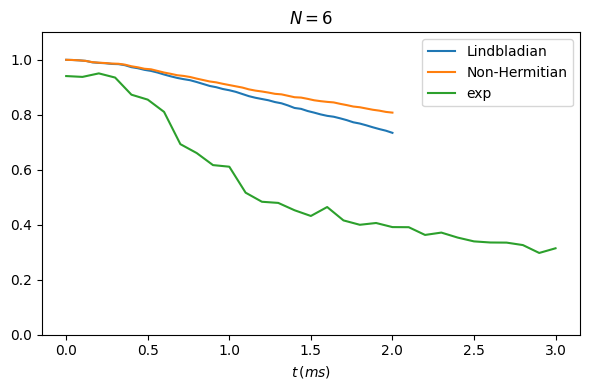

In [ ]:
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels,
    plot_fractions
)

for n, data_dir in zip(n_particles, DATA_SUBDIR_FULL):
    # (batch, time, k)
    params = load_params(data_dir)
    state_norm_square_nh = load_nh_state_norm_square(data_dir)
    total_nums_nh = 2 * np.mean(state_norm_square_nh, axis=0) + (n - 2)
    
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    nums_up_avg = np.mean(nums_up, axis=0)
    nums_down_avg = np.mean(nums_down, axis=0)
    total_nums_lindblad = np.sum(nums_up_avg, axis=-1) + np.sum(nums_down_avg, axis=-1)
    
    save_at = load_times(data_dir)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ts = save_at * t_r
    ax.set_title(f"$N={n}$")
    ax.plot(ts, total_nums_lindblad / n, label='Lindbladian')
    ax.plot(ts, total_nums_nh / n, label='Non-Hermitian')
    ax.plot(exp_time, exp_nums, label='exp')
    ax.legend()
    ax.set_ylim(0.0, 1.1)
    ax.set_xlabel("$t\\,(ms)$")

    plt.tight_layout()
    plt.show()